# Lesson 2.4 — Numerical Validation: Geometric J vs Finite Differences
**Module 6 · Unit 2 · Lesson 8**

The discipline of the whole module: never trust a Jacobian you haven't checked. We finite-difference the forward kinematics — central differences for the linear part, and a rotation difference + vee for the angular part — and confirm it matches the analytic geometric Jacobian, with the expected **second-order** convergence.

In [1]:
import numpy as np

def skew(v):
    v=np.asarray(v,float).ravel()
    return np.array([[0,-v[2],v[1]],[v[2],0,-v[0]],[-v[1],v[0],0]])
def vee(S): return np.array([S[2,1],S[0,2],S[1,0]])

def dh(theta,d,a,alpha):
    # one Denavit-Hartenberg link transform
    ct,st,ca,sa=np.cos(theta),np.sin(theta),np.cos(alpha),np.sin(alpha)
    return np.array([[ct,-st*ca, st*sa, a*ct],
                     [st, ct*ca,-ct*sa, a*st],
                     [0,  sa,    ca,    d   ],
                     [0,  0,     0,     1   ]])

def forward_chain(params,jtypes,q):
    # returns T_0^0..T_0^n ; revolute adds q to theta, prismatic adds q to d
    T=np.eye(4); Ts=[T.copy()]
    for i,(th0,d0,a,al) in enumerate(params):
        th,d=(th0+q[i],d0) if jtypes[i]=="R" else (th0,d0+q[i])
        T=T@dh(th,d,a,al); Ts.append(T.copy())
    return Ts

def geometric_jacobian(params,jtypes,q):
    # base-frame 6xn geometric Jacobian (D-057: [v; omega], linear on top)
    Ts=forward_chain(params,jtypes,q); o_n=Ts[-1][:3,3]; n=len(q); J=np.zeros((6,n))
    for i in range(n):
        z=Ts[i][:3,2]; o=Ts[i][:3,3]   # axis & origin of frame i (= z_{i-1}, o_{i-1})
        if jtypes[i]=="R": J[:3,i]=np.cross(z,o_n-o); J[3:,i]=z   # revolute: [z x (o_n-o); z]
        else:             J[:3,i]=z;                   J[3:,i]=0   # prismatic: [z; 0]
    return J

def fk_pose(params,jtypes,q):
    T=forward_chain(params,jtypes,q)[-1]; return T[:3,3], T[:3,:3]


## The finite-difference Jacobian (linear: central diff; angular: ΔR → vee)

In [2]:
checks=[]
def fd_jacobian(params,jtypes,q,eps=1e-6):
    n=len(q); J=np.zeros((6,n))
    for i in range(n):
        e=np.zeros(n); e[i]=eps
        pp,Rp=fk_pose(params,jtypes,q+e); pm,Rm=fk_pose(params,jtypes,q-e)
        J[:3,i]=(pp-pm)/(2*eps)              # linear: central difference of position
        M=Rp@Rm.T                            # angular: R(q+) R(q-)^T ~ I + S(2 eps w)
        J[3:,i]=vee((M-M.T)/2)/(2*eps)
    return J

## Agreement across revolute, prismatic-mixed, and spatial chains

In [3]:
# 2R planar
p2=[(0,0,1,0),(0,0,1,0)]; t2=["R","R"]
# spatial 3R
p3=[(0,0,0,np.pi/2),(0,0,1,0),(0,0,0.8,0)]; t3=["R","R","R"]
# mixed R-P-R
pm_=[(0,0,0,np.pi/2),(0,0,0,0),(0,0,0.5,0)]; tm=["R","P","R"]
cases=[("2R",p2,t2,np.array([0.3,0.7])),
       ("3R",p3,t3,np.array([0.2,0.5,-0.3])),
       ("RPR",pm_,tm,np.array([0.4,0.3,-0.5]))]
for name,p,t,q in cases:
    err=np.linalg.norm(geometric_jacobian(p,t,q)-fd_jacobian(p,t,q))
    print(f"{name:4s}  ||J_geo - J_fd|| = {err:.2e}")
    checks.append(err<1e-5)

2R    ||J_geo - J_fd|| = 1.37e-10
3R    ||J_geo - J_fd|| = 1.59e-10
RPR   ||J_geo - J_fd|| = 5.07e-11


## Convergence: central differences are second-order in the step size

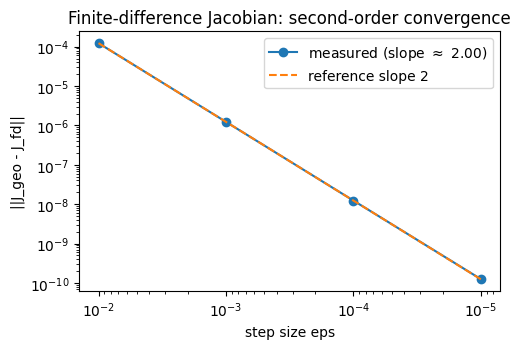

slope = 2.0


In [4]:
import matplotlib.pyplot as plt
q=np.array([0.2,0.5,-0.3]); Jg=geometric_jacobian(p3,t3,q)
steps=np.array([1e-2,1e-3,1e-4,1e-5])
errs=np.array([np.linalg.norm(fd_jacobian(p3,t3,q,h)-Jg) for h in steps])
slope=np.polyfit(np.log10(steps),np.log10(errs),1)[0]
plt.figure(figsize=(5.2,3.6))
plt.loglog(steps,errs,'o-',label=f'measured (slope $\\approx$ {slope:.2f})')
plt.loglog(steps,errs[0]*(steps/steps[0])**2,'--',label='reference slope 2')
plt.gca().invert_xaxis(); plt.xlabel('step size eps'); plt.ylabel('||J_geo - J_fd||')
plt.title('Finite-difference Jacobian: second-order convergence'); plt.legend(); plt.tight_layout(); plt.show()
print("slope =",round(slope,2))
checks.append(1.7<slope<2.3)

In [5]:
assert all(checks), f"FAILED: {checks}"
print("All checks passed.")

All checks passed.
